# 03 — Importância das variáveis por município

Objetivo: comparar **quais determinantes pesam mais** em cada município da Bahia.

Nomes dos municípios via **API IBGE** (`data/reference/municipios_ba_ibge.csv`).

**Estratégia:** treinar um Random Forest **separado por município de residência**, com o mesmo conjunto de variáveis do modelo final, **exceto município** (constante dentro de cada recorte). A taxa de cesárea suavizada de estabelecimento e Robson é recalculada **apenas no treino daquele município**.

**Critérios:**
- Volume mínimo configurável (`MIN_N`) para estabilidade
- Partição hold-out 80/20 estratificada por município
- Importâncias agregadas por bloco temático (mesma lógica do modelo global)

In [1]:
from __future__ import annotations

import sys
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.columns import Col, FEATURES_V8, TARGET
from ml.dataset import build_xy
from ml.ibge import attach_municipio_nomes, load_municipios_ba, municipio_label
from ml.train import TrainConfig, train_random_forest
from ml.validate import evaluate, feature_importances

warnings.filterwarnings("ignore", category=UserWarning)

DATA_PATH = ROOT / "data/processed/sinasc_ba_features.parquet"
IBGE_PATH = ROOT / "data/reference/municipios_ba_ibge.csv"
OUT_DIR = ROOT / "data/processed"
RANDOM_STATE = 42
TEST_SIZE = 0.2
MIN_N = 500  # mínimo de nascimentos para treinar
TOP_MUNICIPIOS_PLOT = 20  # municípios no heatmap (por volume)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

FEATURES_MUNICIPIO = tuple(
    col for col in FEATURES_V8 if col is not Col.CODIGO_MUNICIPIO_RESIDENCIA
)

FEATURES_MUNICIPIO

(<Col.IDADE_MAE: 'idade_mae'>,
 <Col.QUANTIDADE_PARTOS_CESAREOS_ANTERIORES: 'quantidade_partos_cesareos_anteriores'>,
 <Col.PARIDADE: 'paridade'>,
 <Col.TIPO_GRAVIDEZ: 'tipo_gravidez'>,
 <Col.ESCOLARIDADE_MAE_AGREGADA: 'escolaridade_mae_agregada'>,
 <Col.RACA_COR_MAE: 'raca_cor_mae'>,
 <Col.SEMANAS_GESTACAO: 'semanas_gestacao'>,
 <Col.INDICE_KOTELCHUCK_PRENATAL: 'indice_kotelchuck_prenatal'>,
 <Col.TIPO_APRESENTACAO_FETAL: 'tipo_apresentacao_fetal'>,
 <Col.LOCAL_NASCIMENTO: 'local_nascimento'>,
 <Col.CODIGO_ESTABELECIMENTO_SAUDE: 'codigo_estabelecimento_saude'>,
 <Col.GRUPO_ROBSON: 'grupo_robson'>,
 <Col.QUANTIDADE_PARTOS_VAGINAIS_ANTERIORES: 'quantidade_partos_vaginais_anteriores'>,
 <Col.NASCIMENTO_MESMO_MUNICIPIO_RESIDENCIA: 'nascimento_mesmo_municipio_residencia'>,
 <Col.ESTADO_CIVIL_MAE: 'estado_civil_mae'>,
 <Col.SEXO_RECEM_NASCIDO: 'sexo_recem_nascido'>,
 <Col.RACA_COR_RECEM_NASCIDO: 'raca_cor_recem_nascido'>)

## 1 — Base e volume por município

In [2]:
df = pd.read_parquet(DATA_PATH)
muni_col = Col.CODIGO_MUNICIPIO_RESIDENCIA.value

municipios_ibge = load_municipios_ba(IBGE_PATH)

muni_stats = (
    df.groupby(muni_col)
    .agg(n=(TARGET, "size"), taxa_cesarea=(TARGET, "mean"))
    .sort_values("n", ascending=False)
)
muni_stats.index = muni_stats.index.astype(str).str.strip()
muni_stats = muni_stats.reset_index().rename(columns={muni_col: "municipio"})
muni_stats = attach_municipio_nomes(muni_stats, codigo_col="municipio", path=IBGE_PATH)
muni_stats = muni_stats.set_index("municipio")
muni_stats["elegivel"] = muni_stats["n"] >= MIN_N

print(f"Registros: {len(df):,}")
print(f"Municípios: {muni_stats.shape[0]}")
print(f"Elegíveis (n ≥ {MIN_N}): {muni_stats['elegivel'].sum()}")
muni_stats.sort_values("n", ascending=False).head(12)

Registros: 503,785
Municípios: 418
Elegíveis (n ≥ 500): 223


,n,taxa_cesarea,elegivel
codigo_municipio_residencia,,,
292740,76318,0.511360,True
291080,24701,0.619206,True
293330,14536,0.518368,True
290570,11376,0.487342,True
291840,11255,0.471080,True
292530,8417,0.347867,True
290320,7283,0.551970,True
291920,7198,0.496388,True
293135,6989,0.504221,True


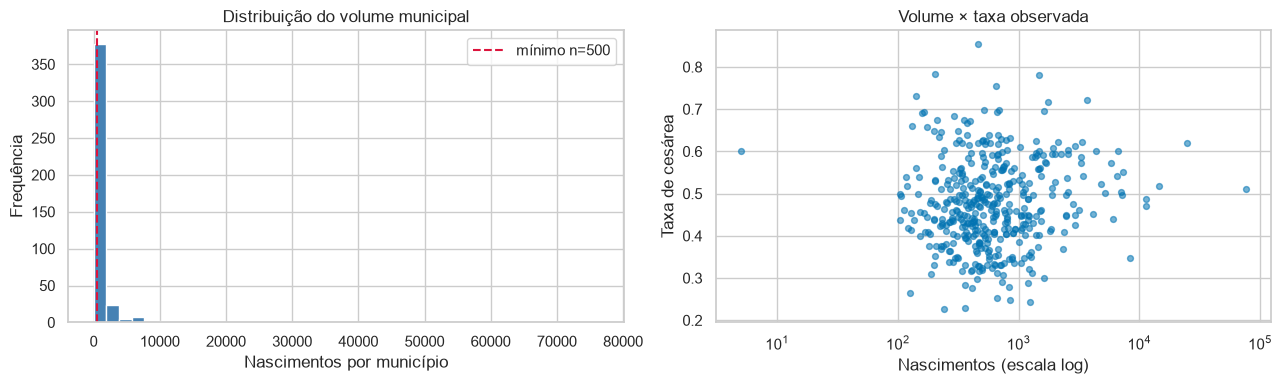

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(muni_stats["n"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(MIN_N, color="crimson", ls="--", label=f"mínimo n={MIN_N}")
axes[0].set_xlabel("Nascimentos por município")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição do volume municipal")
axes[0].legend()

axes[1].scatter(muni_stats["n"], muni_stats["taxa_cesarea"], alpha=0.55, s=18)
axes[1].set_xscale("log")
axes[1].set_xlabel("Nascimentos (escala log)")
axes[1].set_ylabel("Taxa de cesárea")
axes[1].set_title("Volume × taxa observada")

plt.tight_layout()
plt.show()

## 2 — Funções auxiliares

In [4]:
FEATURE_LABELS = {
    "grupo_robson": "Robson",
    "codigo_estabelecimento_saude": "Estabelecimento",
    "quantidade_partos_cesareos_anteriores": "Cesáreas anteriores",
    "quantidade_partos_vaginais_anteriores": "Partos vaginais anteriores",
    "idade_mae": "Idade materna",
    "semanas_gestacao": "Idade gestacional",
    "escolaridade_mae_agregada": "Escolaridade",
    "paridade": "Paridade",
    "indice_kotelchuck_prenatal": "Pré-natal (Kotelchuck)",
    "tipo_gravidez": "Tipo de gravidez",
    "raca_cor_mae": "Raça/cor mãe",
    "raca_cor_recem_nascido": "Raça/cor RN",
    "estado_civil_mae": "Estado civil",
    "sexo_recem_nascido": "Sexo RN",
    "tipo_apresentacao_fetal": "Apresentação fetal",
    "local_nascimento": "Local nascimento",
    "nascimento_mesmo_municipio_residencia": "Nasceu no município de residência",
}


def aggregate_importances(importances: pd.Series) -> pd.Series:
    """Agrega dummies e colunas target-encoded por prefixo de variável."""
    grouped: dict[str, float] = defaultdict(float)
    for name, value in importances.items():
        if name.endswith("_taxa_cesarea"):
            base = name.removesuffix("_taxa_cesarea")
        elif "_" in name and name.rsplit("_", 1)[-1].isdigit():
            base = name.rsplit("_", 1)[0]
        else:
            base = name
        grouped[base] += value
    series = pd.Series(grouped).sort_values(ascending=False)
    return series.rename(index=lambda k: FEATURE_LABELS.get(k, k))


def train_municipio(
    muni_df: pd.DataFrame,
    *,
    random_state: int = RANDOM_STATE,
    test_size: float = TEST_SIZE,
) -> dict | None:
    if len(muni_df) < MIN_N:
        return None
    if muni_df[TARGET].nunique() < 2:
        return None

    try:
        train_df, test_df = train_test_split(
            muni_df,
            test_size=test_size,
            random_state=random_state,
            stratify=muni_df[TARGET],
        )
    except ValueError:
        return None

    if train_df[TARGET].nunique() < 2 or test_df[TARGET].nunique() < 2:
        return None

    x_train, y_train, encoder = build_xy(train_df, FEATURES_MUNICIPIO)
    x_test, y_test = build_xy(test_df, FEATURES_MUNICIPIO, encoder=encoder)

    cfg = TrainConfig(random_state=random_state, n_jobs=-1)
    model = train_random_forest(x_train, y_train, cfg)
    imp_raw = feature_importances(model, list(x_train.columns))
    imp_agg = aggregate_importances(imp_raw)
    metrics = evaluate(model, x_test, y_test)

    return {
        "n": len(muni_df),
        "taxa_cesarea": float(muni_df[TARGET].mean()),
        "metrics": metrics,
        "importances_raw": imp_raw,
        "importances": imp_agg,
    }

## 3 — Treinar modelo por município

Pode levar alguns minutos (~200 municípios elegíveis × Random Forest).

In [5]:
eligible = muni_stats.index[muni_stats["elegivel"]].tolist()
results: dict[str, dict] = {}
skipped = 0

for i, muni in enumerate(eligible, start=1):
    subset = df[df[muni_col] == muni]
    out = train_municipio(subset)
    if out is None:
        skipped += 1
        continue
    results[muni] = out
    if i % 25 == 0 or i == len(eligible):
        print(f"{i}/{len(eligible)} processados · {len(results)} modelos OK · {skipped} ignorados")

print(f"\nModelos treinados: {len(results)}")

25/223 processados · 25 modelos OK · 0 ignorados
50/223 processados · 50 modelos OK · 0 ignorados
75/223 processados · 75 modelos OK · 0 ignorados
100/223 processados · 100 modelos OK · 0 ignorados
125/223 processados · 125 modelos OK · 0 ignorados
150/223 processados · 150 modelos OK · 0 ignorados
175/223 processados · 175 modelos OK · 0 ignorados
200/223 processados · 200 modelos OK · 0 ignorados
223/223 processados · 223 modelos OK · 0 ignorados

Modelos treinados: 223


In [6]:
metrics_rows = []
imp_rows = []

for muni, payload in results.items():
    row = {"municipio": muni, "n": payload["n"], "taxa_cesarea": payload["taxa_cesarea"]}
    row.update({f"metric_{k}": v for k, v in payload["metrics"].items()})
    metrics_rows.append(row)

    for feat, score in payload["importances"].items():
        imp_rows.append({"municipio": muni, "variavel": feat, "importancia": score})

metrics_df = pd.DataFrame(metrics_rows).sort_values("n", ascending=False)
imp_df = pd.DataFrame(imp_rows)
imp_wide = imp_df.pivot(index="municipio", columns="variavel", values="importancia").fillna(0)

metrics_df.head(10)

,municipio,n,taxa_cesarea,metric_accuracy,metric_f1,metric_roc_auc
0,292740,76318,0.511360,0.763561,0.768014,0.849526
1,291080,24701,0.619206,0.823113,0.856013,0.894085
2,293330,14536,0.518368,0.752063,0.739052,0.826712
3,290570,11376,0.487342,0.786028,0.779338,0.868663
4,291840,11255,0.471080,0.820080,0.809591,0.898161
5,292530,8417,0.347867,0.802257,0.726376,0.875047
6,290320,7283,0.551970,0.768703,0.781027,0.851944
7,291920,7198,0.496388,0.768056,0.772169,0.853565
8,293135,6989,0.504221,0.775393,0.755832,0.845465
9,291955,6604,0.600848,0.788039,0.818887,0.872351


## 4 — Modelo global de referência (sem município)

In [7]:
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df[TARGET]
)
x_train, y_train, enc = build_xy(train_df, FEATURES_MUNICIPIO)
x_test, y_test = build_xy(test_df, FEATURES_MUNICIPIO, encoder=enc)
global_model = train_random_forest(x_train, y_train, TrainConfig(random_state=RANDOM_STATE, n_jobs=-1))
global_imp = aggregate_importances(feature_importances(global_model, list(x_train.columns)))
global_metrics = evaluate(global_model, x_test, y_test)

print("Modelo global (referência):")
for k, v in global_metrics.items():
    print(f"  {k}: {v:.3f}")
print("\nTop 8 importâncias agregadas:")
global_imp.head(8)

Modelo global (referência):
  accuracy: 0.790
  f1: 0.788
  roc_auc: 0.877

Top 8 importâncias agregadas:


Estabelecimento               0.265656
Robson                        0.258640
Cesáreas anteriores           0.118020
Idade materna                 0.076117
Partos vaginais anteriores    0.070218
Idade gestacional             0.044224
Escolaridade                  0.037050
Pré-natal (Kotelchuck)        0.026724
dtype: float64

## 5 — Heatmap: municípios × determinantes

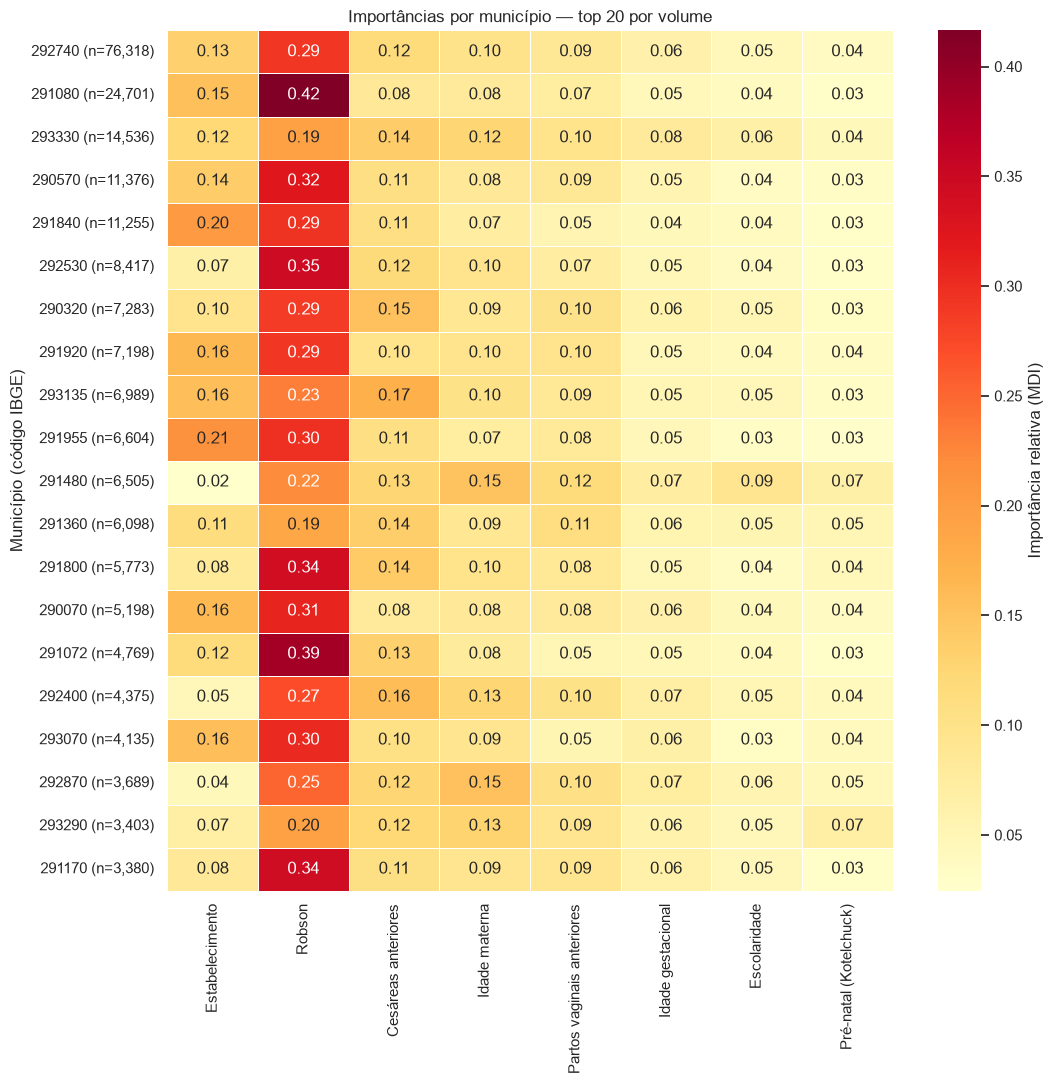

In [8]:
top_rows = metrics_df.head(TOP_MUNICIPIOS_PLOT)
top_names = top_rows["nome_municipio"].tolist()
top_vars = global_imp.head(8).index.tolist()

heat = imp_wide.loc[top_names, top_vars]
heat.index = [
    municipio_label(row["nome_municipio"], row["nome_municipio"], n=int(row["n"]))
    for _, row in top_rows.iterrows()
]

fig, ax = plt.subplots(figsize=(11, 0.45 * len(top_names) + 2))
sns.heatmap(
    heat,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Importância relativa (MDI)"},
    ax=ax,
)
ax.set_title(f"Importâncias por município — top {TOP_MUNICIPIOS_PLOT} por volume")
ax.set_xlabel("")
ax.set_ylabel("Município")
plt.tight_layout()
plt.show()

## 6 — Determinante #1 por município

Determinante mais importante (1º lugar) — frequência entre municípios:


variavel
Robson                        131
Estabelecimento                89
Idade materna                   2
Partos vaginais anteriores      1
Name: count, dtype: int64

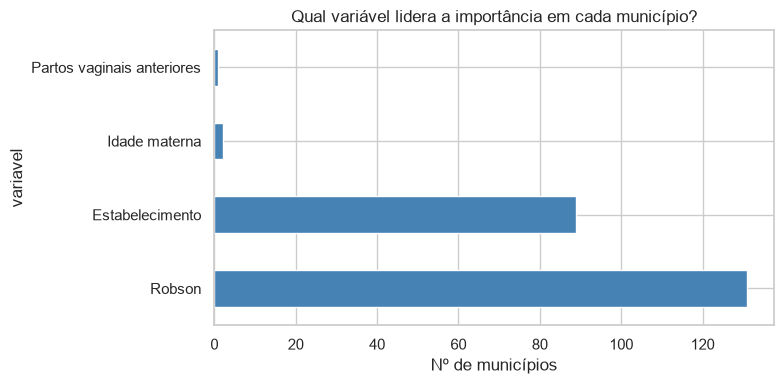

,municipio,variavel,importancia,n,taxa_cesarea
174,292740,Robson,0.291830,76318,0.511360
71,291080,Robson,0.416414,24701,0.619206
220,293330,Robson,0.193558,14536,0.518368
32,290570,Robson,0.323606,11376,0.487342
116,291840,Robson,0.294874,11255,0.471080
159,292530,Robson,0.346552,8417,0.347867
13,290320,Robson,0.286928,7283,0.551970
120,291920,Robson,0.291289,7198,0.496388
207,293135,Robson,0.232002,6989,0.504221
122,291955,Robson,0.298530,6604,0.600848


In [9]:
top1 = (
    imp_df.sort_values("importancia", ascending=False)
    .groupby("municipio", as_index=False)
    .first()
    .merge(metrics_df[["municipio", "nome_municipio", "n", "taxa_cesarea"]], on="municipio")
    .sort_values("n", ascending=False)
)

top1_counts = top1["variavel"].value_counts()
print("Determinante mais importante (1º lugar) — frequência entre municípios:")
display(top1_counts)

fig, ax = plt.subplots(figsize=(8, 4))
top1_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Nº de municípios")
ax.set_title("Qual variável lidera a importância em cada município?")
plt.tight_layout()
plt.show()

top1[["nome_municipio", "municipio", "variavel", "importancia", "n", "taxa_cesarea"]].head(15)

## 7 — Comparar municípios selecionados vs. global

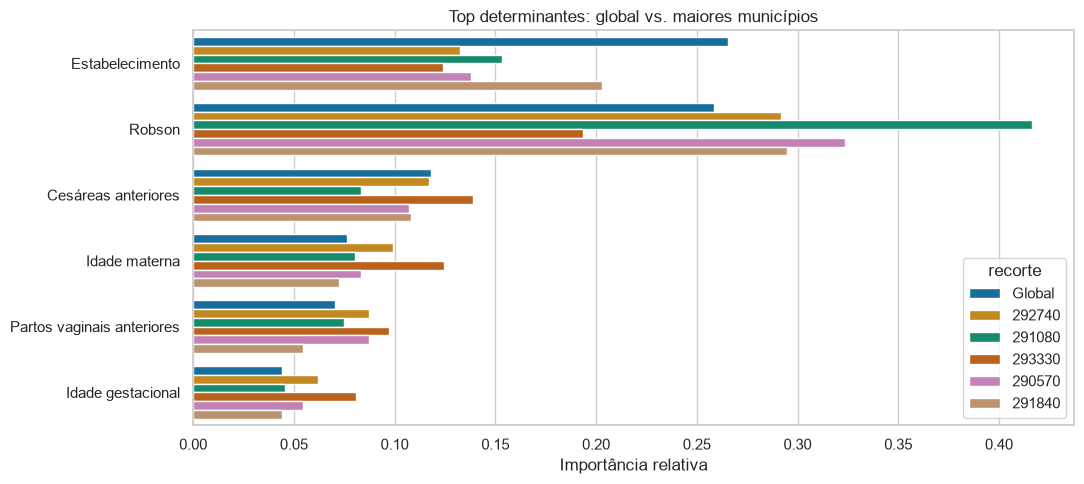

In [10]:
COMPARE = metrics_df.head(5)["municipio"].tolist()  # top 5 por volume
compare_vars = global_imp.head(6).index.tolist()

plot_df = pd.DataFrame({"variavel": compare_vars, "Global": global_imp.reindex(compare_vars).values})
for muni in COMPARE:
    plot_df[muni] = imp_wide.loc[muni, compare_vars].values

plot_long = plot_df.melt(id_vars="variavel", var_name="recorte", value_name="importancia")

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_long, x="importancia", y="variavel", hue="recorte", ax=ax)
ax.set_title("Top determinantes: global vs. maiores municípios")
ax.set_xlabel("Importância relativa")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8 — Desempenho municipal vs. taxa observada

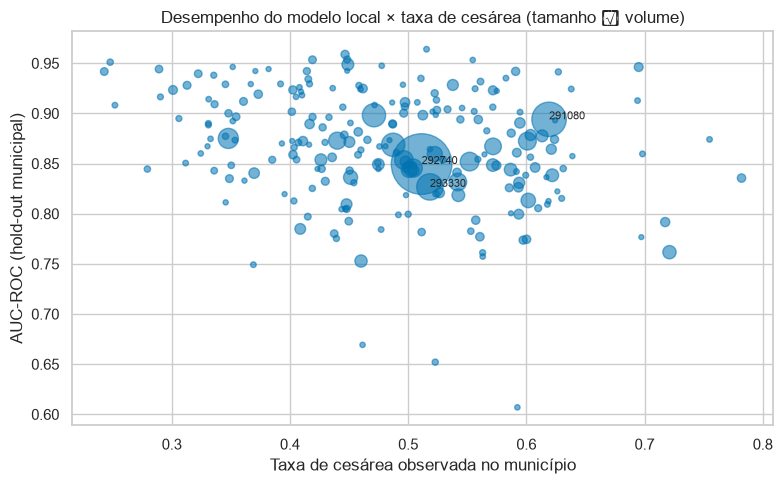

,n,taxa_cesarea,metric_roc_auc,metric_f1
count,223.000000,223.000000,223.000000,223.000000
mean,1981.964126,0.483576,0.866945,0.779853
std,5553.287528,0.103523,0.055758,0.067685
min,504.000000,0.242892,0.606944,0.560748
25%,660.000000,0.410582,0.837372,0.739526
50%,895.000000,0.480843,0.869987,0.780142
75%,1497.000000,0.562108,0.908765,0.833333
max,76318.000000,0.782016,0.963956,0.925843


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(metrics_df["taxa_cesarea"], metrics_df["metric_roc_auc"], s=metrics_df["n"] / 40, alpha=0.55)
ax.set_xlabel("Taxa de cesárea observada no município")
ax.set_ylabel("AUC-ROC (hold-out municipal)")
ax.set_title("Desempenho do modelo local × taxa de cesárea (tamanho ∝ volume)")

for _, row in metrics_df.head(3).iterrows():
    ax.annotate(row["nome_municipio"], (row["taxa_cesarea"], row["metric_roc_auc"]), fontsize=8)

plt.tight_layout()
plt.show()

metrics_df[["nome_municipio", "municipio", "n", "taxa_cesarea", "metric_roc_auc", "metric_f1"]].describe()

## 9 — Exportar resultados

In [12]:
metrics_path = OUT_DIR / "importancia_municipio_metricas.parquet"
imp_path = OUT_DIR / "importancia_municipio_larga.parquet"

metrics_df.to_parquet(metrics_path, index=False)
imp_df.to_parquet(imp_path, index=False)

print(f"Métricas → {metrics_path}")
print(f"Importâncias → {imp_path}")

Métricas → /Users/antonielmagalhaes/d/acad/ia-final/ia-iii/data/processed/importancia_municipio_metricas.parquet
Importâncias → /Users/antonielmagalhaes/d/acad/ia-final/ia-iii/data/processed/importancia_municipio_larga.parquet
